# Backtesting VaR/ES Models

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from matplotlib import pyplot as plt

import sys
sys.path.append("../src")
from risklib.plot_utils import shade_regimes

In [3]:
# Load return series
port_returns = pd.read_csv("../data/returns.csv", parse_dates=[0], index_col=0)[['Portfolio']]
port_loss = -port_returns

# Load VaR & ES series we want to test
port_var99 = pd.read_csv("../outputs/port_var99.csv", parse_dates=[0], index_col=0)
port_es99 = pd.read_csv("../outputs/port_es99.csv", parse_dates=[0], index_col=0)
port_var95 = pd.read_csv("../outputs/port_var95.csv", parse_dates=[0], index_col=0)
port_es95 = pd.read_csv("../outputs/port_es95.csv", parse_dates=[0], index_col=0)

port_var99_Copula = pd.read_csv("../outputs/port_var99_Copula.csv", parse_dates=[0], index_col=0)
port_es99_Copula = pd.read_csv("../outputs/port_es99_Copula.csv", parse_dates=[0], index_col=0)
port_var95_Copula = pd.read_csv("../outputs/port_var95_Copula.csv", parse_dates=[0], index_col=0)
port_es95_Copula = pd.read_csv("../outputs/port_es95_Copula.csv", parse_dates=[0], index_col=0)
port_var99_Copula.columns = ['Copula']
port_es99_Copula.columns = ['Copula']
port_var95_Copula.columns = ['Copula']
port_es95_Copula.columns = ['Copula']

port_var99_EVT_Copula = pd.read_csv("../outputs/port_var99_EVT_Copula.csv", parse_dates=[0], index_col=0)
port_es99_EVT_Copula = pd.read_csv("../outputs/port_es99_EVT_Copula.csv", parse_dates=[0], index_col=0)
port_var95_EVT_Copula = pd.read_csv("../outputs/port_var95_EVT_Copula.csv", parse_dates=[0], index_col=0)
port_es95_EVT_Copula = pd.read_csv("../outputs/port_es95_EVT_Copula.csv", parse_dates=[0], index_col=0)
port_var99_EVT_Copula.columns = ['EVT+Copula']
port_es99_EVT_Copula.columns = ['EVT+Copula']
port_var95_EVT_Copula.columns = ['EVT+Copula']
port_es95_EVT_Copula.columns = ['EVT+Copula']

port_var99 = pd.concat([port_var99, port_var99_Copula, port_var99_EVT_Copula], axis=1)
port_var95 = pd.concat([port_var95, port_var95_Copula, port_var95_EVT_Copula], axis=1)

# methods
methods = [
    'HS',
    'PG',
    'PST',
    'FHS',
    'FPST',
    'Copula',
    'EVT+Copula',
]

## Count Breaches

We count the number of losses that exceed the VaR which is estimated the same day. 

In [5]:
def build_breach(loss_df, var_df, est_window=504):
    T = len(var_df)
    breach_loss = np.full((T,), np.nan).tolist()
    for i in range(est_window, T):
        if var_df.values[i] < loss_df.values[i]:
            breach_loss[i] = True
        else:
            breach_loss[i] = False
    breach_loss = pd.DataFrame(breach_loss, index=var_df.index)
    n_breach = int(breach_loss.dropna().sum().values[0])
    return breach_loss, n_breach, T-est_window

breach_var99, breach_var95 = {}, {}
for met in methods:
    breach_loss_99, n_breach_99, n_total_99 = build_breach(port_loss, port_var99[[met]], est_window=504)
    breach_loss_95, n_breach_95, n_total_95 = build_breach(port_loss, port_var95[[met]], est_window=504)
    breach_var99[met] = {'b_loss': breach_loss_99, 'n_breach': n_breach_99, 'n_total': n_total_99}
    breach_var95[met] = {'b_loss': breach_loss_95, 'n_breach': n_breach_95, 'n_total': n_total_95}
    print(f"99% VaR (method: {met}) : n_breach = {n_breach_99},  n_total = {n_total_99} | 95% VaR : n_breach = {n_breach_95},  n_total = {n_total_95}")

99% VaR (method: HS) : n_breach = 78,  n_total = 4777 | 95% VaR : n_breach = 277,  n_total = 4777
99% VaR (method: PG) : n_breach = 112,  n_total = 4777 | 95% VaR : n_breach = 269,  n_total = 4777
99% VaR (method: PST) : n_breach = 64,  n_total = 4777 | 95% VaR : n_breach = 297,  n_total = 4777
99% VaR (method: FHS) : n_breach = 63,  n_total = 4777 | 95% VaR : n_breach = 248,  n_total = 4777
99% VaR (method: FPST) : n_breach = 71,  n_total = 4777 | 95% VaR : n_breach = 301,  n_total = 4777
99% VaR (method: Copula) : n_breach = 47,  n_total = 4777 | 95% VaR : n_breach = 255,  n_total = 4777
99% VaR (method: EVT+Copula) : n_breach = 50,  n_total = 4777 | 95% VaR : n_breach = 267,  n_total = 4777


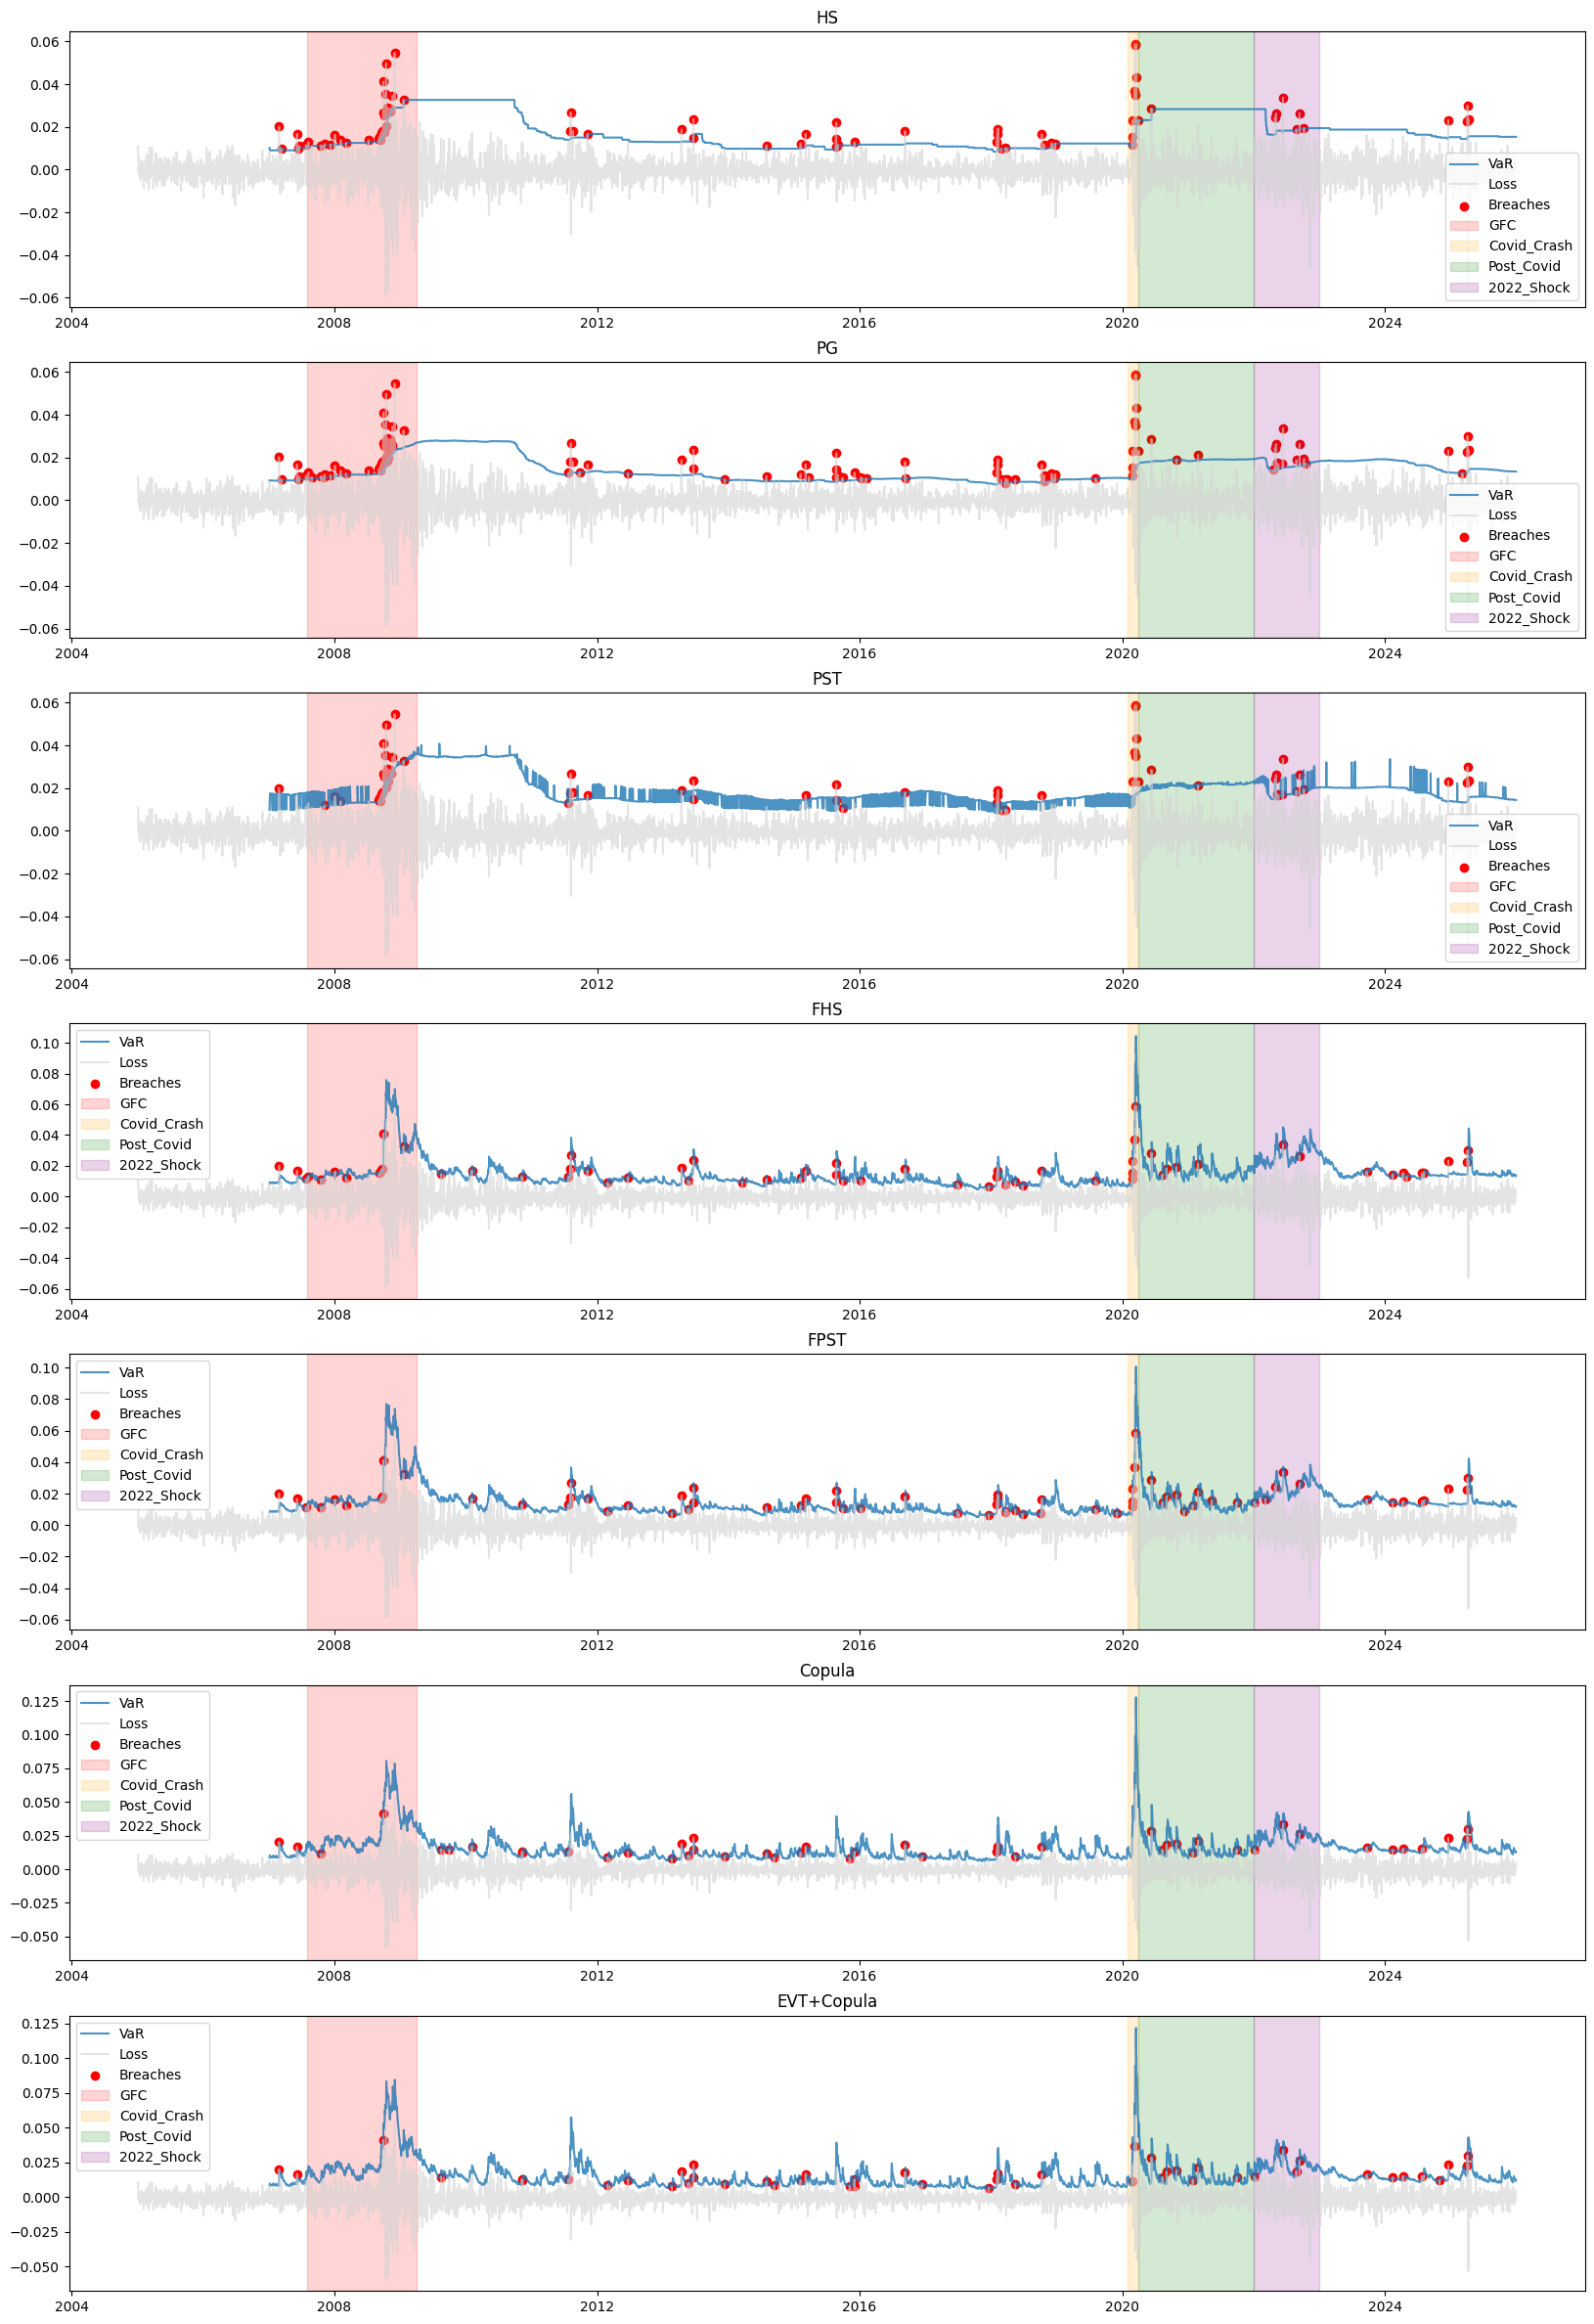

In [12]:
# Plot breaches of different methods
fig, ax = plt.subplots(len(methods), 1, figsize=(20,30))
for met,a in zip(methods,ax.flat):
    b_data = breach_var99[met]
    a.plot(port_var99[met], label='VaR', alpha=0.8) 
    a.plot(port_loss, label='Loss', color='lightgrey', alpha=0.6)
    breach_pts = port_loss[b_data['b_loss'].fillna(False).values]
    a.scatter(breach_pts.index, breach_pts.values, color='red', label='Breaches')
    a.set_title(met)
    shade_regimes(a)
    a.legend()

## Coverage & Independence

- Kupiec Test
- Christoffersen Test

### Kupiec Test

In [21]:
'''
def kupiec_pof(b_series, alpha):
    #print(b_series)
    n_breach = int(b_series.dropna().sum().values[0])
    n_total = len(b_series)
    b_rate = n_breach / n_total   # breach rate

    if n_breach == 0 or n_breach == n_total:
        # Edge case: b_rate = 0 or 1
        lr = np.nan
        p_val = stats.binom.cdf(0, n_total, alpha) if n_breach == 0 else 1.0
    else:
        lr = -2 * ((n_total - n_breach)*np.log((1-alpha)/(1-b_rate)) + n_breach*np.log(alpha/b_rate))
        # p_val of the calculated lr on a chi-square dist with df=1
        p_val = 1 - stats.chi2.cdf(lr, df=1)
    pass_POF = bool(p_val > 0.05)
    return pass_POF
'''

def kupiec_pof(b_series, alpha):
    ''' Kupiec's Portion of Failure test
    '''
    #print(b_series)
    n_breach = int(b_series.dropna().sum().values[0])
    n_total = len(b_series)
    if n_total == 0: return np.nan
    b_rate = n_breach / n_total   # breach rate

    if n_breach == 0:
        lr = -2 * n_total * np.log(1 - alpha)
    elif n_breach == n_total:
        lr = -2 * n_total * np.log(alpha)
    else:
        lr = -2 * ((n_total - n_breach) * np.log((1 - alpha) / (1 - b_rate))
                   + n_breach * np.log(alpha / b_rate))

    p_val = stats.chi2.sf(lr, df=1)   # sf is more accurate than 1 - cdf in the tail
    return bool(p_val > 0.05)



# Rolling Kupiec Test (window=250)
window = 250
kupiec_res_99, kupiec_res_95 = {}, {}
for met in methods:
    b_loss_99, b_loss_95 = breach_var99[met]['b_loss'].dropna(), breach_var95[met]['b_loss'].dropna()
    res_99, res_95 = np.full((len(b_loss_99),), np.nan), np.full((len(b_loss_95),), np.nan)
    for i in range(window-1, len(b_loss_99)):
        b_series_99, b_series_95 = b_loss_99[i-window+1:i+1], b_loss_95[i-window+1:i+1]
        res_99[i], res_95[i] = kupiec_pof(b_series_99, alpha=0.01), kupiec_pof(b_series_95, alpha=0.05)
    kupiec_res_99[met], kupiec_res_95[met] = res_99, res_95
    
kupiec_res_99 = pd.DataFrame(kupiec_res_99, index=breach_var99['HS']['b_loss'].dropna().index)
kupiec_res_95 = pd.DataFrame(kupiec_res_95, index=breach_var95['HS']['b_loss'].dropna().index)

In [46]:
# Calculate Kupiec test pass rate
kupiec_pass_rate = {}
for met in methods:
    pr_99 = (kupiec_res_99[met].dropna().sum()/ len(kupiec_res_99[met].dropna()))
    pr_95 = kupiec_res_95[met].dropna().sum()/ len(kupiec_res_95[met].dropna())
    kupiec_pass_rate[met] = [pr_95, pr_99]
kupiec_pass_rate = pd.DataFrame(kupiec_pass_rate, index=["Kupiec 95%", "Kupiec 99%"])

kupiec_pass_rate

,HS,PG,PST,FHS,FPST,Copula,EVT+Copula
Kupiec 95%,0.502871,0.494920,0.485203,0.951634,0.767447,0.927120,0.889355
Kupiec 99%,0.554549,0.459364,0.579505,0.928666,0.861749,0.953401,0.940592


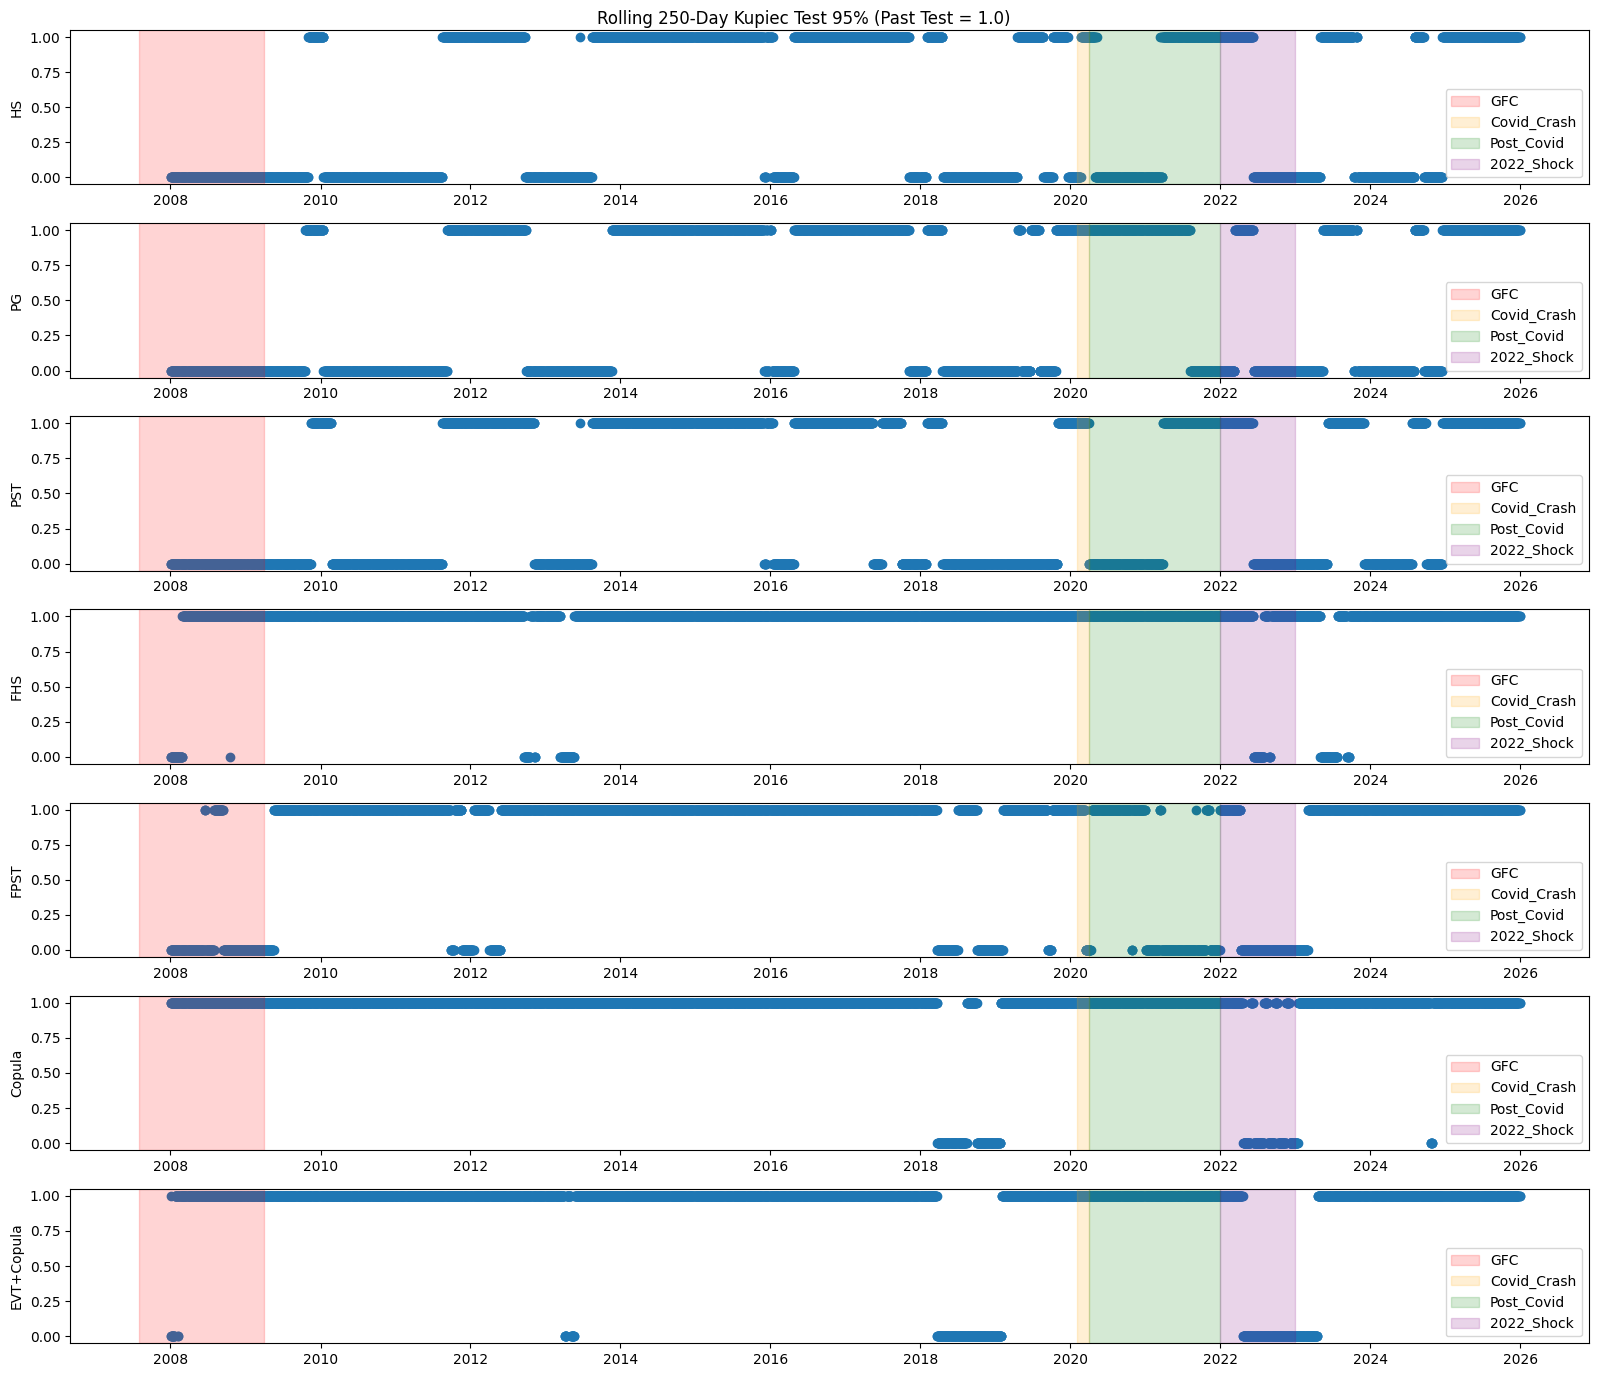

In [49]:
# Plot kupiec results (95% VaR)
fig, ax = plt.subplots(len(methods), 1, figsize=(16,14))
for met,a in zip(methods,ax.flat):
    a.scatter(kupiec_res_95.index, kupiec_res_95[met])
    shade_regimes(a)
    a.set_ylabel(f"{met}")
    a.legend()

plt.suptitle("Rolling 250-Day Kupiec Test 95% (Past Test = 1.0)")
plt.savefig("../plots/kupiec_95_res.png")
plt.tight_layout()

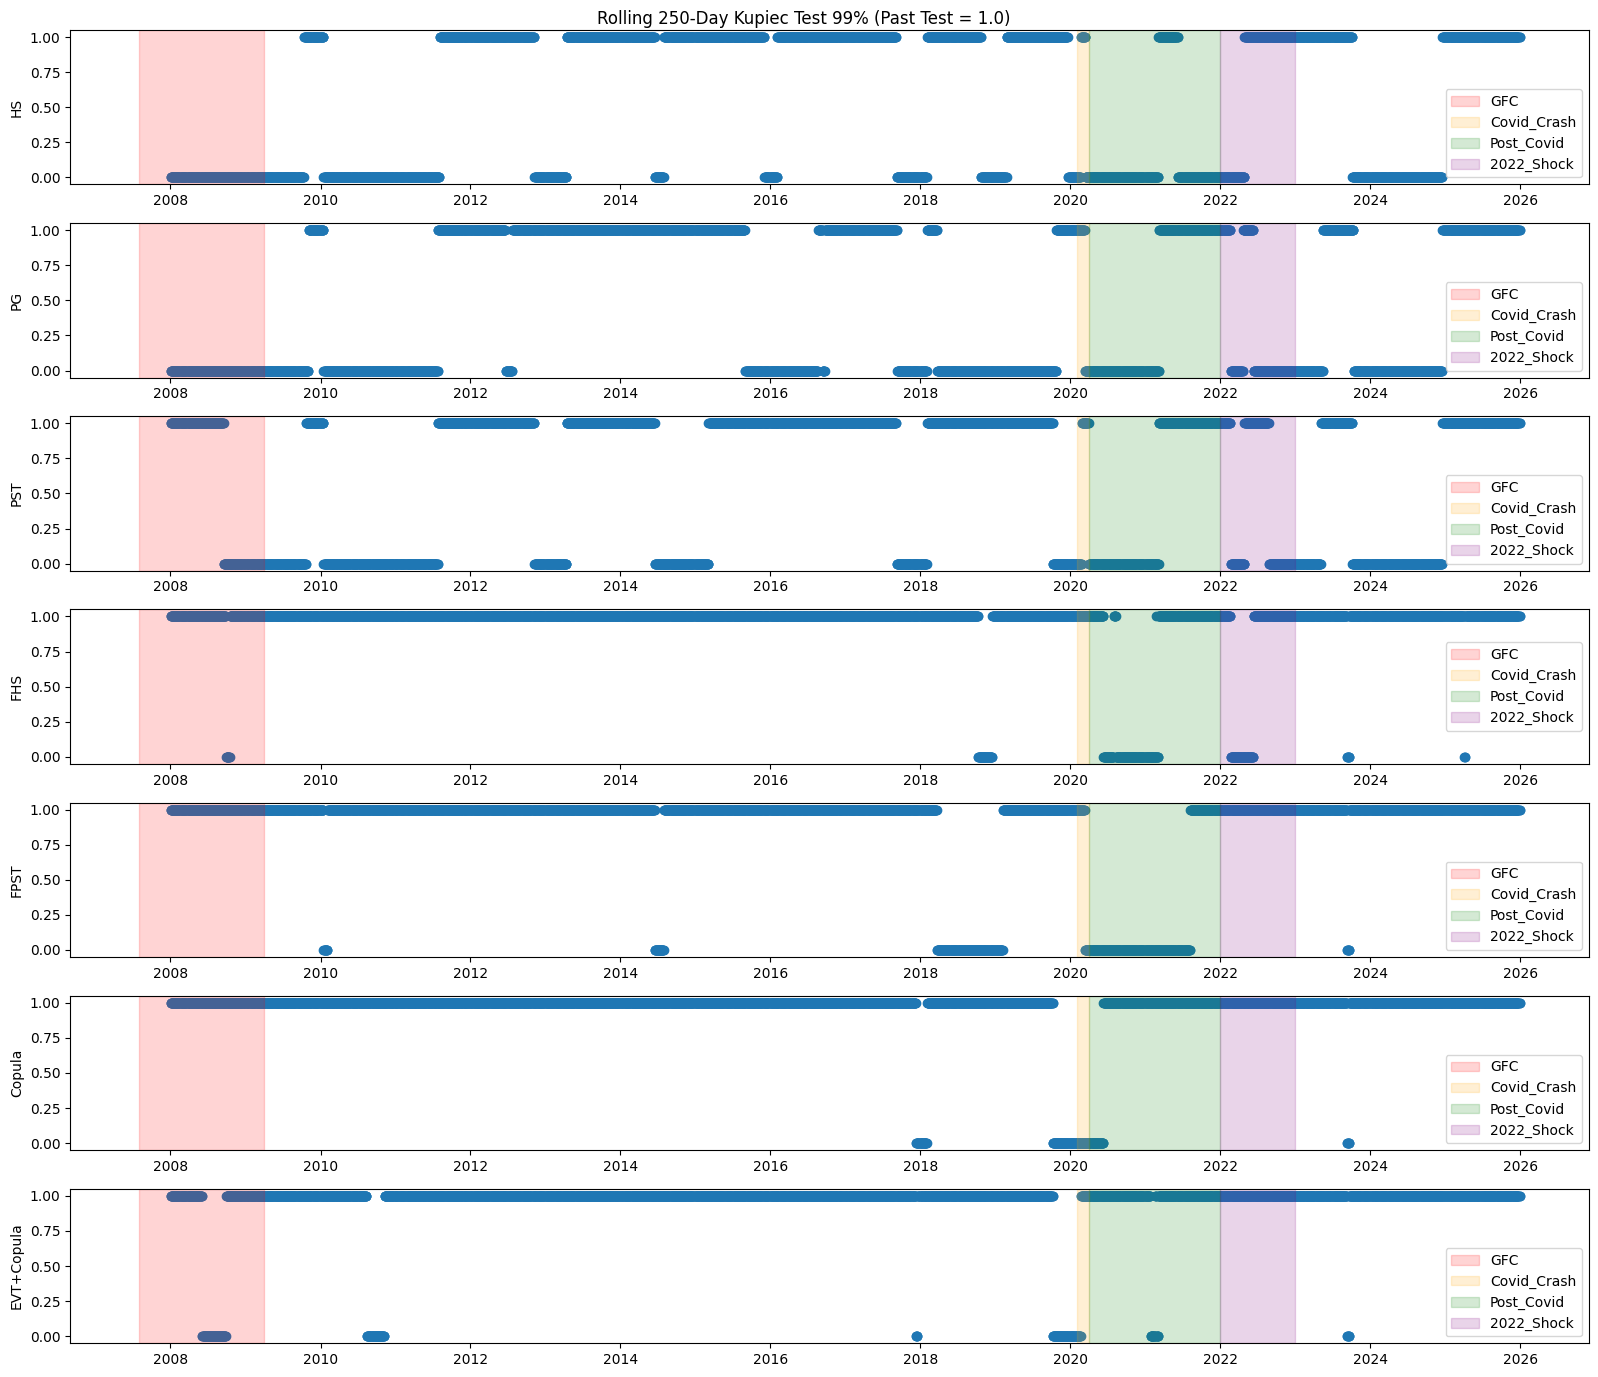

In [51]:
# Plot kupiec results (99% VaR)
fig, ax = plt.subplots(len(methods), 1, figsize=(16,14))
for met,a in zip(methods,ax.flat):
    a.scatter(kupiec_res_99.index, kupiec_res_99[met])
    shade_regimes(a)
    a.set_ylabel(f"{met}")
    a.legend()

plt.suptitle("Rolling 250-Day Kupiec Test 99% (Past Test = 1.0)")
plt.savefig("../plots/kupiec_99_res.png")
plt.tight_layout()

### Independence Test

In [25]:
def christoff_ind(b_series):
    ''' Christffersen Independence Test
    '''
    b_series = b_series.dropna().values.astype(int)
    n_breach = int(b_series.sum())
    n_total = len(b_series)

    n00 = np.sum((b_series[:-1]==0) & (b_series[1:]==0))
    n01 = np.sum((b_series[:-1]==0) & (b_series[1:]==1))
    n10 = np.sum((b_series[:-1]==1) & (b_series[1:]==0))
    n11 = np.sum((b_series[:-1]==1) & (b_series[1:]==1))

    pi01 = n01/(n00+n01) if (n00+n01)>0 else 0
    pi11 = n11/(n10+n11) if (n10+n11)>0 else 0
    pi   = (n01+n11) / (n_total-1)

    def slog(x):
        return np.log(max(x, 1e-10))

    L1 = (n00*slog(1-pi01) + n01*slog(pi01) +
          n10*slog(1-pi11) + n11*slog(pi11))
    L0 = ((n00+n10)*slog(1-pi) + (n01+n11)*slog(pi))
    lr = -2 * (L0 - L1)
    p_val   = 1 - stats.chi2.cdf(lr, df=1)
    pass_Ind = p_val > 0.05
    return pass_Ind

# Rolling Christoffersen Test (window=250)
window = 250
christoff_res_99, christoff_res_95 = {}, {}
for met in methods:
    b_loss_99, b_loss_95 = breach_var99[met]['b_loss'].dropna(), breach_var95[met]['b_loss'].dropna()
    res_99, res_95 = np.full((len(b_loss_99),), np.nan), np.full((len(b_loss_95),), np.nan)
    for i in range(window-1, len(b_loss_99)):
        b_series_99, b_series_95 = b_loss_99[i-window+1:i+1], b_loss_95[i-window+1:i+1]
        res_99[i], res_95[i] = christoff_ind(b_series_99), christoff_ind(b_series_95)
    christoff_res_99[met], christoff_res_95[met] = res_99, res_95
    
christoff_res_99 = pd.DataFrame(christoff_res_99, index=breach_var99['HS']['b_loss'].dropna().index)
christoff_res_95 = pd.DataFrame(christoff_res_95, index=breach_var95['HS']['b_loss'].dropna().index)

In [47]:
# Calculate Independence test pass rate
indep_pass_rate = {}
for met in methods:
    pr_99 = christoff_res_99[met].dropna().sum()/ len(christoff_res_99[met].dropna())
    pr_95 = christoff_res_95[met].dropna().sum()/ len(christoff_res_95[met].dropna())
    indep_pass_rate[met] = [pr_95, pr_99]
indep_pass_rate = pd.DataFrame(indep_pass_rate, index=["Christoffersen 95%", "Christoffersen 99%"])

indep_pass_rate

,HS,PG,PST,FHS,FPST,Copula,EVT+Copula
Christoffersen 95%,0.833701,0.792182,0.810512,0.842535,0.800574,0.857332,0.854903
Christoffersen 99%,0.808746,0.807862,0.840989,0.935954,0.924912,0.894435,0.875000


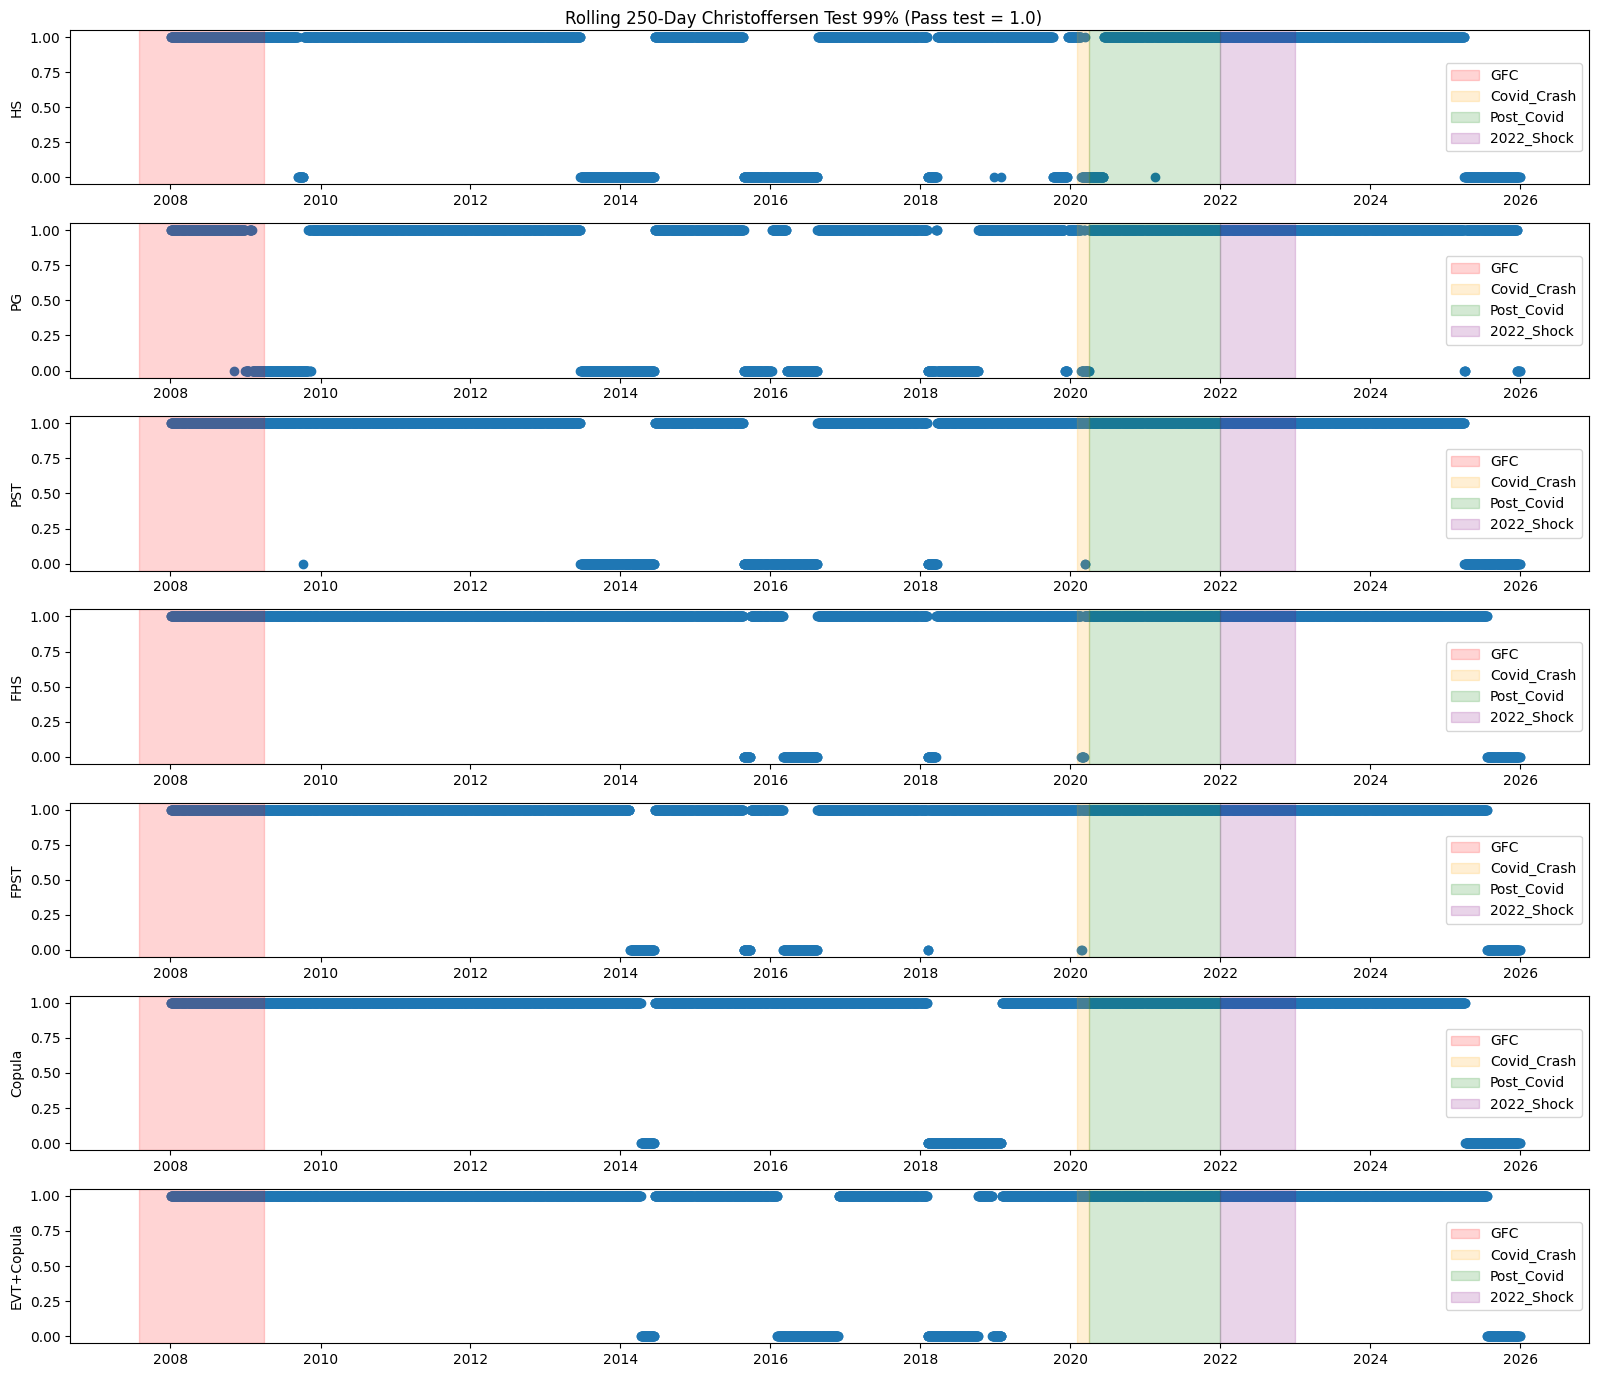

In [52]:
# Plot Christoffersen test results (99%)
fig, ax = plt.subplots(len(methods), 1, figsize=(16,14))
for met,a in zip(methods,ax.flat):
    a.scatter(christoff_res_99.index, christoff_res_99[met])
    shade_regimes(a)
    a.set_ylabel(f"{met}")
    a.legend()

plt.suptitle("Rolling 250-Day Christoffersen Test 99% (Pass test = 1.0)")
plt.savefig("../plots/indep_99_res.png")
plt.tight_layout()

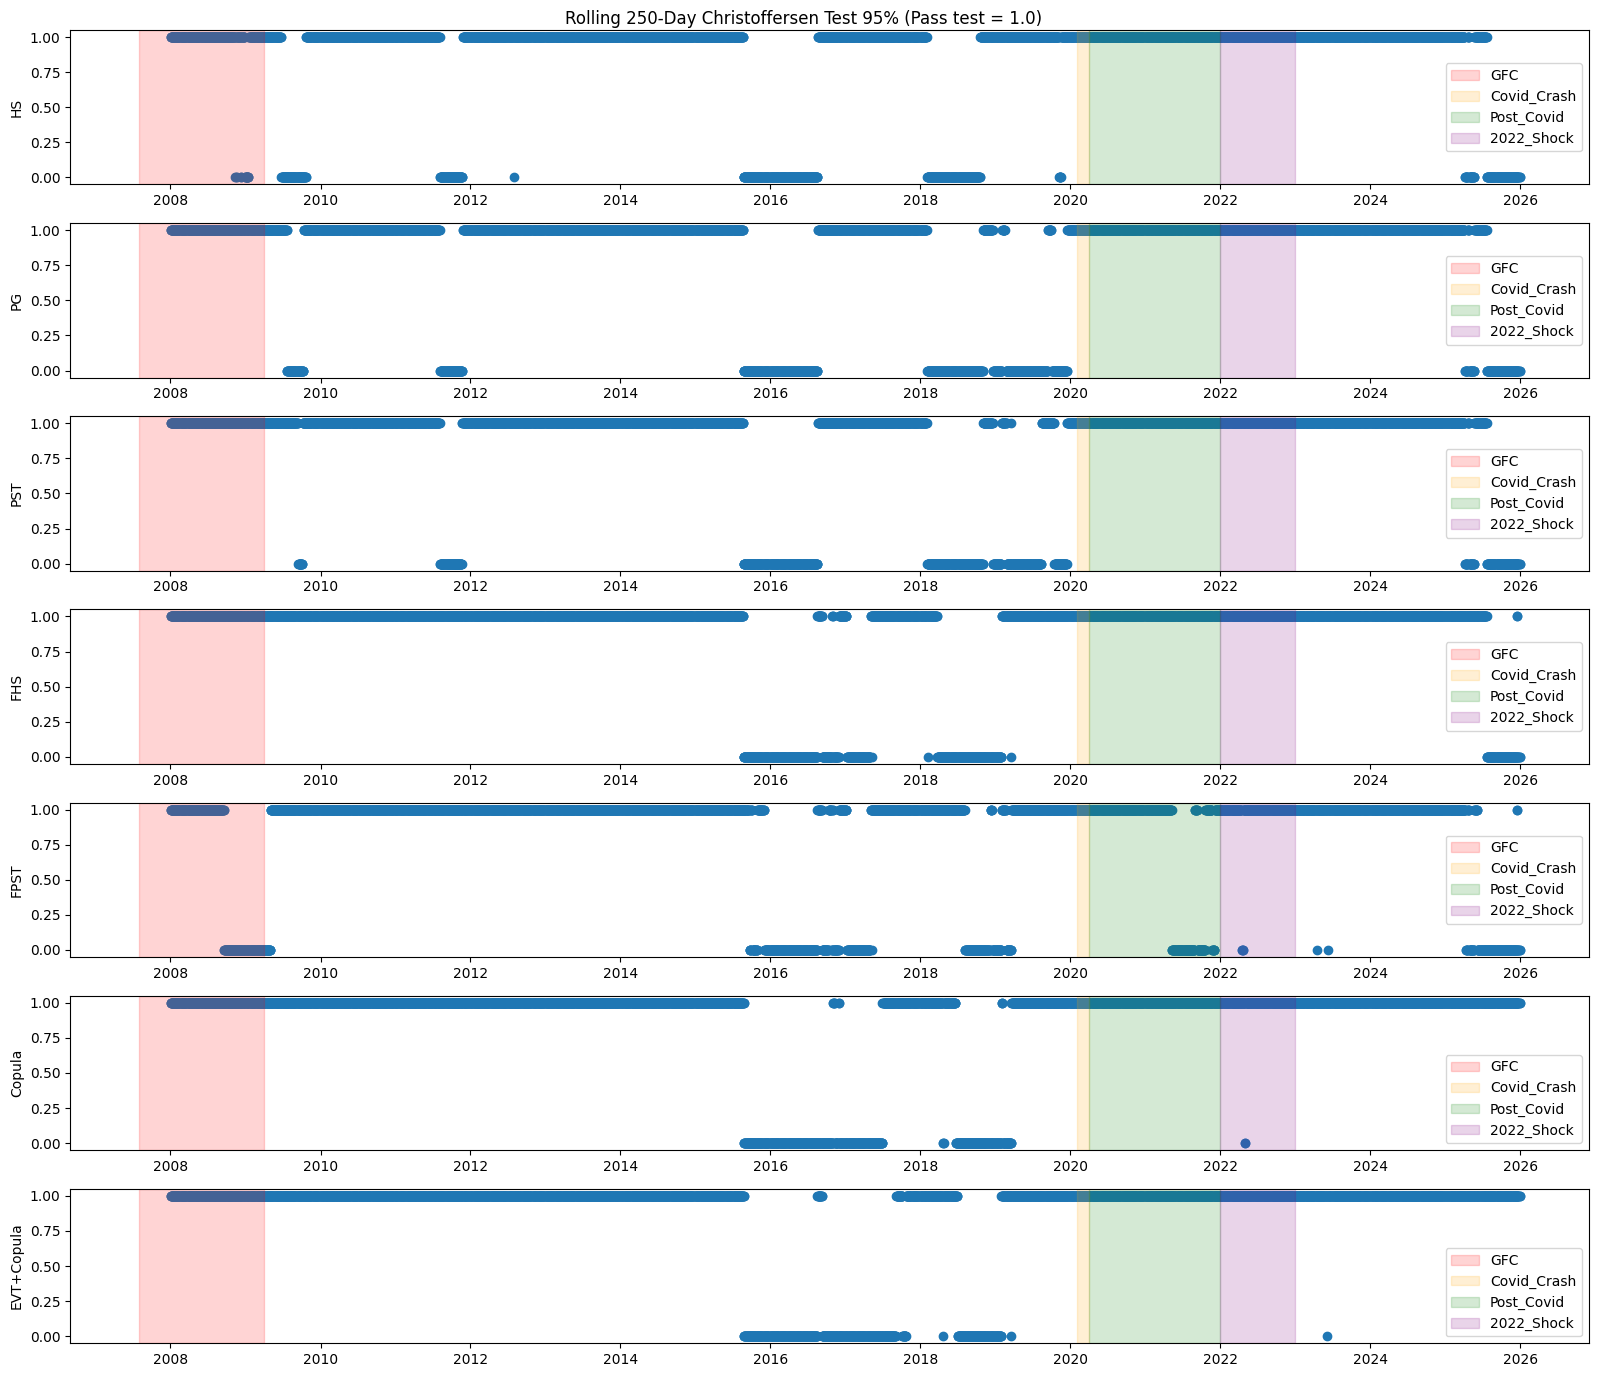

In [53]:
# Plot Christoffersen test results (95%)
fig, ax = plt.subplots(len(methods), 1, figsize=(16,14))
for met,a in zip(methods,ax.flat):
    a.scatter(christoff_res_95.index, christoff_res_95[met])
    shade_regimes(a)
    a.set_ylabel(f"{met}")
    a.legend()

plt.suptitle("Rolling 250-Day Christoffersen Test 95% (Pass test = 1.0)")
plt.savefig("../plots/indep_95_res.png")
plt.tight_layout()

### Basel Traffic Light

In [31]:
def basel_traffic_light(b_series):
    ''' Basel - Rule of Traffic Light - based on results of the recent 250 days (len(b_series)=250)
     - Green:  0 ~ 4 breaches
     - Yellow: 5 ~ 9 breaches
     - Red:    > 9   breaches
    '''
    n_breach = int(b_series.dropna().sum().values[0])
    if n_breach <= 4:
        zone, multi = 'Green', 3.00
    elif n_breach <= 9:
        multi_map = {5:3.40, 6:3.50, 7:3.65, 8:3.75, 9:3.85}
        zone, multi = 'Yellow', multi_map.get(n_breach, 3.85)
    else:
        zone, multi = 'Red', 4.00
    return {
        'zone': zone,
        'multiplier': multi,
    }

basel_traffic_light(breach_var99['FHS']['b_loss'].dropna()[-250:])

{'zone': 'Green', 'multiplier': 3.0}

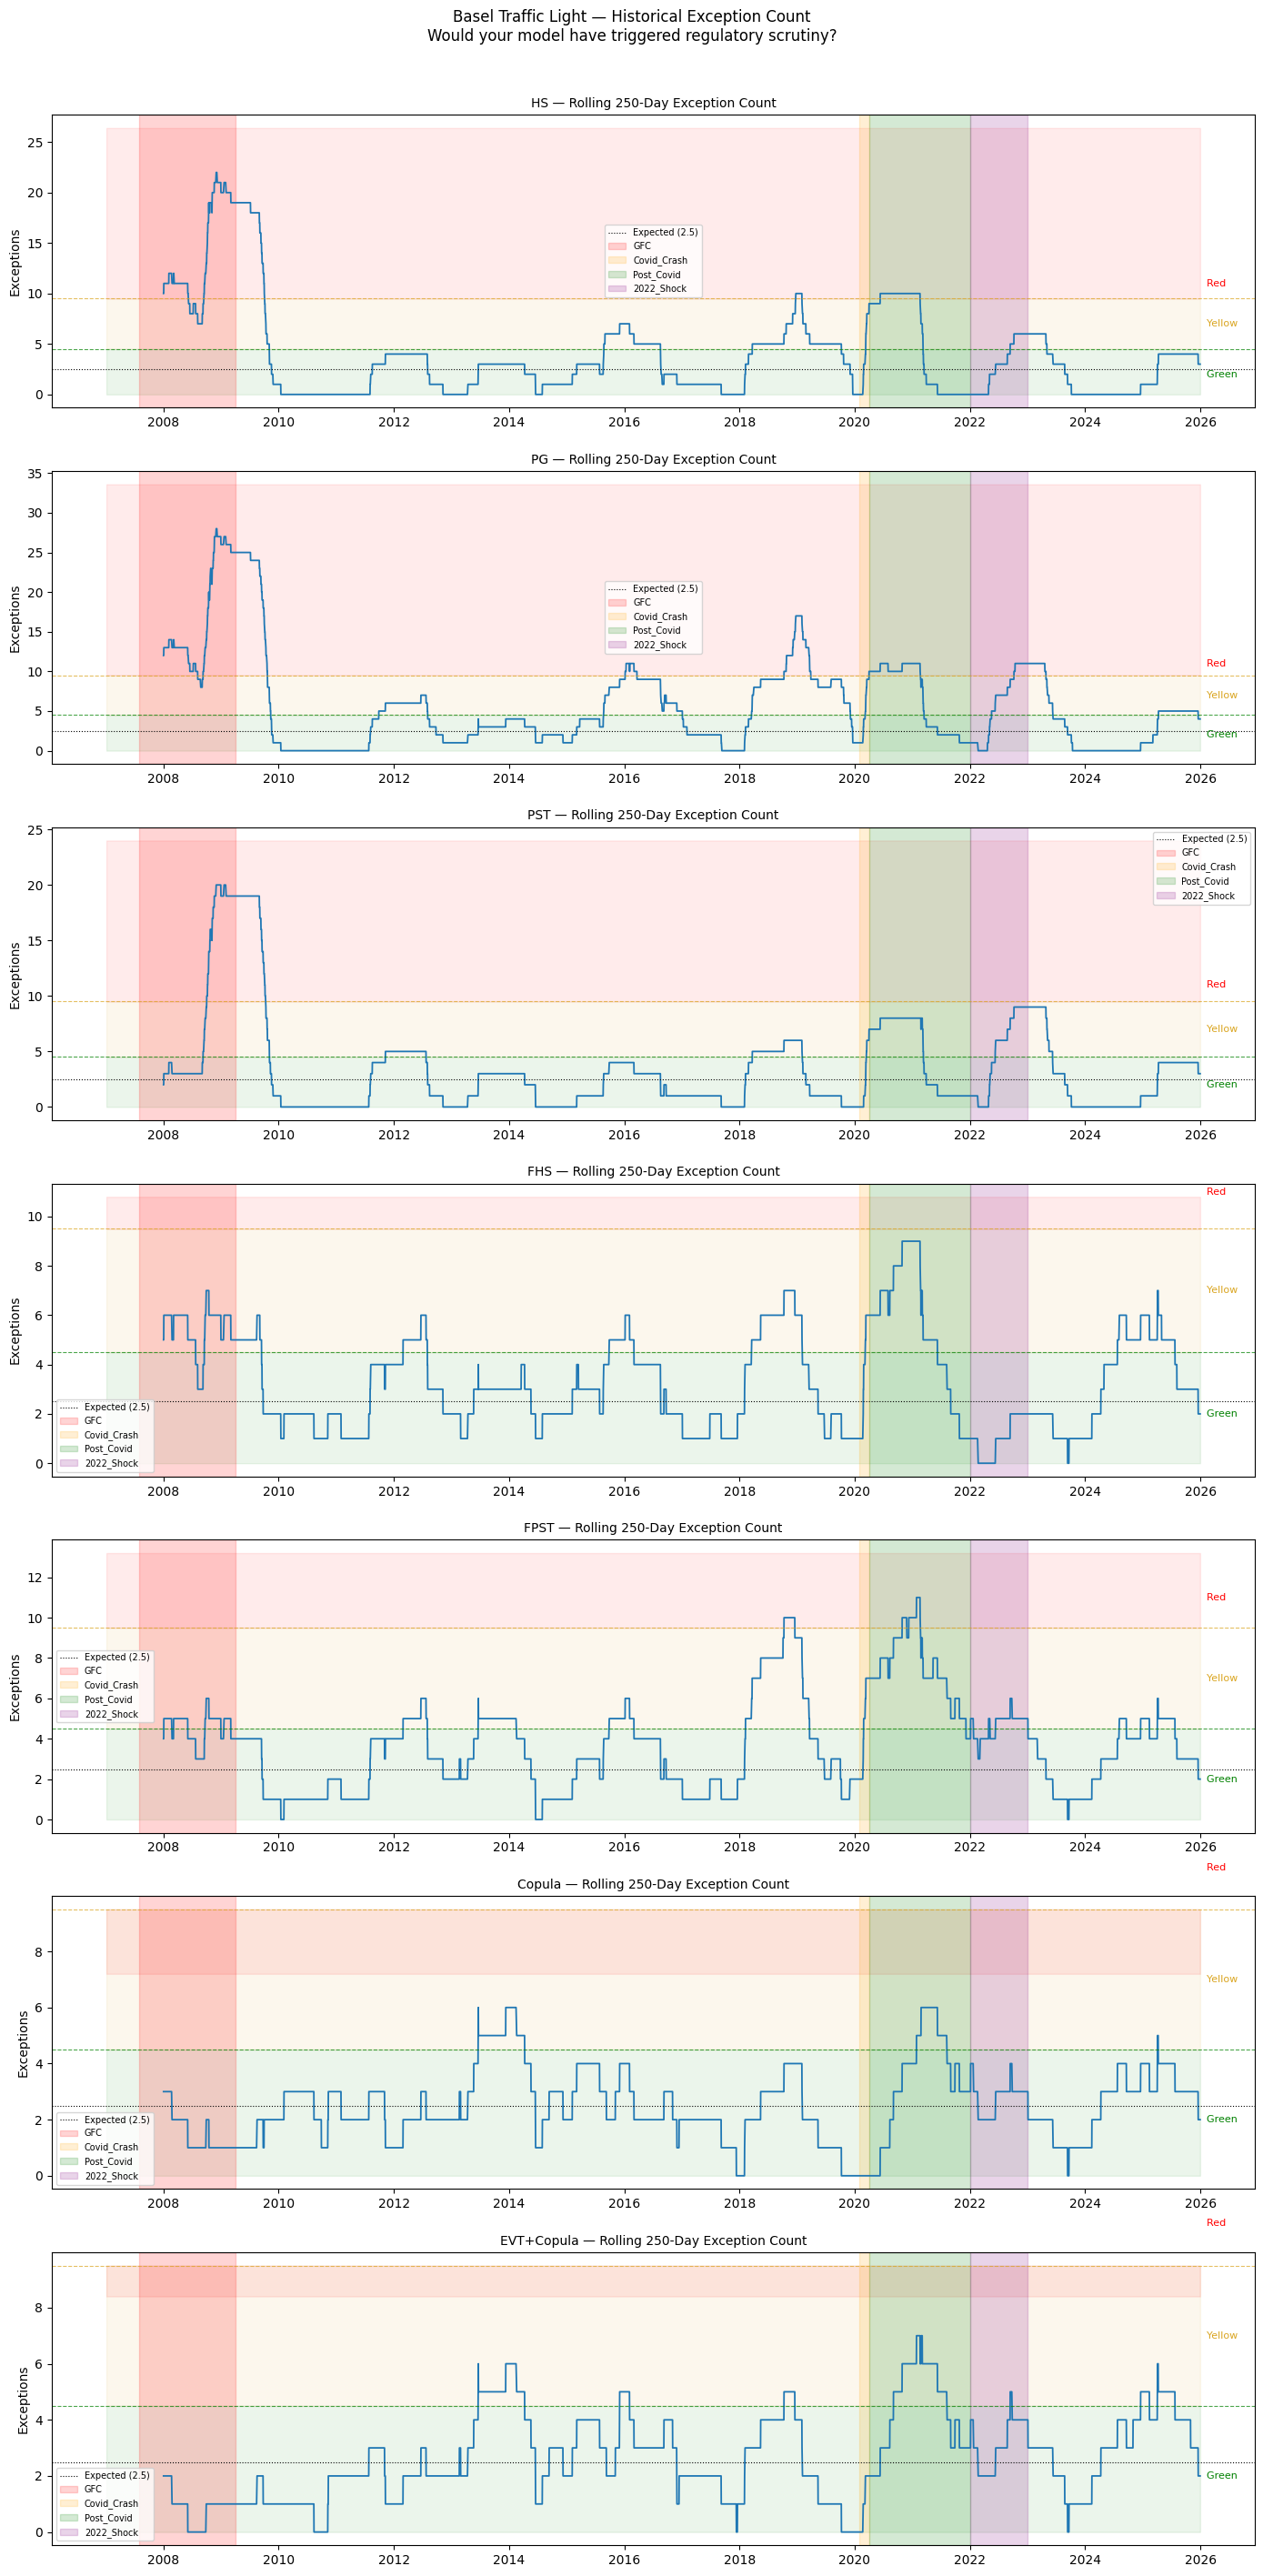

In [54]:
# Show how classification would have evolved historically
# Recompute annually — shows if model ever would have been
# flagged during GFC or 2022

fig, ax = plt.subplots(len(methods),1, figsize=(14, 4*len(methods)))

for met,a in zip(methods, ax.flat):
    b_series = breach_var99[met]['b_loss'].dropna()

    # Rolling 250-day exception count
    roll_breach = b_series.rolling(250).sum()

    # Color background by zone
    a.fill_between(roll_breach.index, 0, 4.5,
                    alpha=0.08, color='green')
    a.fill_between(roll_breach.index, 4.5, 9.5,
                    alpha=0.08, color='goldenrod')
    a.fill_between(roll_breach.index, 9.5, roll_breach.max()*1.2,
                    alpha=0.08, color='red')

    a.plot(roll_breach, lw=1.3)
    a.axhline(2.5, color='black', lw=0.8, linestyle=':', label='Expected (2.5)')
    a.axhline(4.5, color='green',    lw=0.8, linestyle='--', alpha=0.7)
    a.axhline(9.5, color='goldenrod', lw=0.8, linestyle='--', alpha=0.7)

    shade_regimes(a)
    a.set_title(f'{met} — Rolling 250-Day Exception Count',
                 fontsize=10)
    a.set_ylabel('Exceptions')
    a.legend(fontsize=7)

    # Annotate zone labels
    a.text(roll_breach.index[-1], 2.0,  '  Green',
            color='green',    fontsize=8, va='center')
    a.text(roll_breach.index[-1], 7.0,  '  Yellow',
            color='goldenrod', fontsize=8, va='center')
    a.text(roll_breach.index[-1], 11.0, '  Red',
            color='red',      fontsize=8, va='center')

plt.suptitle('Basel Traffic Light — Historical Exception Count\n'
             'Would your model have triggered regulatory scrutiny?',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("../plots/basel_traffic_res.png")
plt.show()